## **Proyect 1: MLP fraude financiero en casos de menos de 1000$ dolares**

- Juan Pablo Solis
- Andre Yatmian Jo Mai

---

## **Análisis Exploratorio de Datos (EDA)**

### 1. Imports y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

### 2. Carga y unión de datos

In [2]:
# Cargar transacciones
train_tx = pd.read_csv('csv/train_transaction.csv')
test_tx  = pd.read_csv('csv/test_transaction.csv')

train_tx['split'] = 'train'
test_tx['split']  = 'test'

combined_tx = pd.concat([train_tx, test_tx], ignore_index=True)

print("Transacciones shape:", combined_tx.shape)

C:\Users\15-4JO\AppData\Local\Temp\ipykernel_29100\3978721052.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_tx['split'] = 'train'
C:\Users\15-4JO\AppData\Local\Temp\ipykernel_29100\3978721052.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_tx['split']  = 'test'


Transacciones shape: (1097231, 395)


In [3]:
# Cargar identidad
train_id = pd.read_csv('csv/train_identity.csv')
test_id  = pd.read_csv('csv/test_identity.csv')

combined_id = pd.concat([train_id, test_id], ignore_index=True)

print("Identidad shape:", combined_id.shape)

Identidad shape: (286140, 79)


In [4]:
# Unir ambos datasets por TransactionID
df = combined_tx.merge(combined_id, on='TransactionID', how='left')

# Variables de referencia
target_col = 'isFraud'
train_only = df[df['split'] == 'train']

print("Dataset final shape:", df.shape)
df.head()

Dataset final shape: (1097231, 473)


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,M6,M7,M8,M9,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,split,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,id-10,id-11,id-12,id-13,id-14,id-15,id-16,id-17,id-18,id-19,id-20,id-21,id-22,id-23,id-24,id-25,id-26,id-27,id-28,id-29,id-30,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38
0,2987000,0.0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,F,T,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,117.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Na

### 3. Vista general del dataset

In [5]:
# Tipos de variables
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1097231 entries, 0 to 1097230
Columns: 473 entries, TransactionID to id-38
dtypes: float64(423), int64(3), str(47)
memory usage: 3.9 GB


In [6]:
# Estadísticas descriptivas
df.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,V41,V42,V43,V44,V45,V46,V47,V48,V49,V50,V51,V52,V53,V54,V55,V56,V57,V58,V59,V60,V61,V62,V63,V64,V65,V66,V67,V68,V69,V70,V71,V72,V73,V74,V75,V76,V77,V78,V79,V80,V81,V82,V83,V84,V85,V86,V87,V88,V89,V90,V91,V92,V93,V94,V95,V96,V97,V98,V99,V100,V101,V102,V103,V104,V105,V106,V107,V108,V109,V110,V111,V112,V113,V114,V115,V116,V117,V118,V119,V120,V121,V122,V123,V124,V125,V126,V127,V128,V129,V130,V131,V132,V133,V134,V135,V136,V137,V138,V139,V140,V141,V142,V143,V144,V145,V146,V147,V148,V149,V150,V151,V152,V153,V154,V155,V156,V157,V158,V159,V160,V161,V162,V163,V164,V165,V166,V167,V168,V169,V170,V171,V172,V173,V174,V175,V176,V177,V178,V179,V180,V181,V182,V183,V184,V185,V186,V187,V188,V189,V190,V191,V192,V193,V194,V195,V196,V197,V198,V199,V200,V201,V202,V203,V204,V205,V206,V207,V208,V209,V210,V211,V212,V213,V214,V215,V216,V217,V218,V219,V220,V221,V222,V223,V224,V225,V226,V227,V228,V229,V230,V231,V232,V233,V234,V235,V236,V237,V238,V239,V240,V241,V242,V243,V244,V245,V246,V247,V248,V249,V250,V251,V252,V253,V254,V255,V256,V257,V258,V259,V260,V261,V262,V263,V264,V265,V266,V267,V268,V269,V270,V271,V272,V273,V274,V275,V276,V277,V278,V279,V280,V281,V282,V283,V284,V285,V286,V287,V288,V289,V290,V291,V292,V293,V294,V295,V296,V297,V298,V299,V300,V301,V302,V303,V304,V305,V306,V307,V308,V309,V310,V311,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,id-10,id-11,id-13,id-14,id-17,id-18,id-19,id-20,id-21,id-22,id-24,id-25,id-26,id-32
count,1.097231e+06,590540.000000,1.097231e+06,1.097231e+06,1.097231e+06,1.079644e+06,1.092664e+06,1.088425e+06,965916.000000,965916.000000,453743.000000,74063.000000,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.097228e+06,1.092483e+06,1.097228e+06,1.089931e+06,581665.000000,631211.000000,851458.000000,563015.000000,197970.000000,99050.000000,149264.000000,149264.000000,1.008664e+06,641426.000000,133971.000000,185336.000000,177381.000000,996049.000000,641426.000000,641426.000000,641426.000000,641426.000000,641426.000000,641426.000000,641426.000000,641426.000000,641426.000000,641426.000000,641426.000000,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,1.008569e+06,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,851408.000000,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,1.007236e+06,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,995986.000000,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e+06,1.096917e

### 4. Análisis de valores nulos

In [7]:
# Porcentaje de nulos por columna
null_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
null_pct = null_pct[null_pct > 0]

print(f"Columnas con nulos: {len(null_pct)} de {df.shape[1]}")
print(null_pct)

Columnas con nulos: 467 de 473
id-24    99.568003
id_24    99.567365
id-25    99.540753
id-26    99.540024
id-08    99.538930
           ...    
C8        0.000273
C9        0.000273
C10       0.000273
C12       0.000273
C14       0.000273
Length: 467, dtype: float64


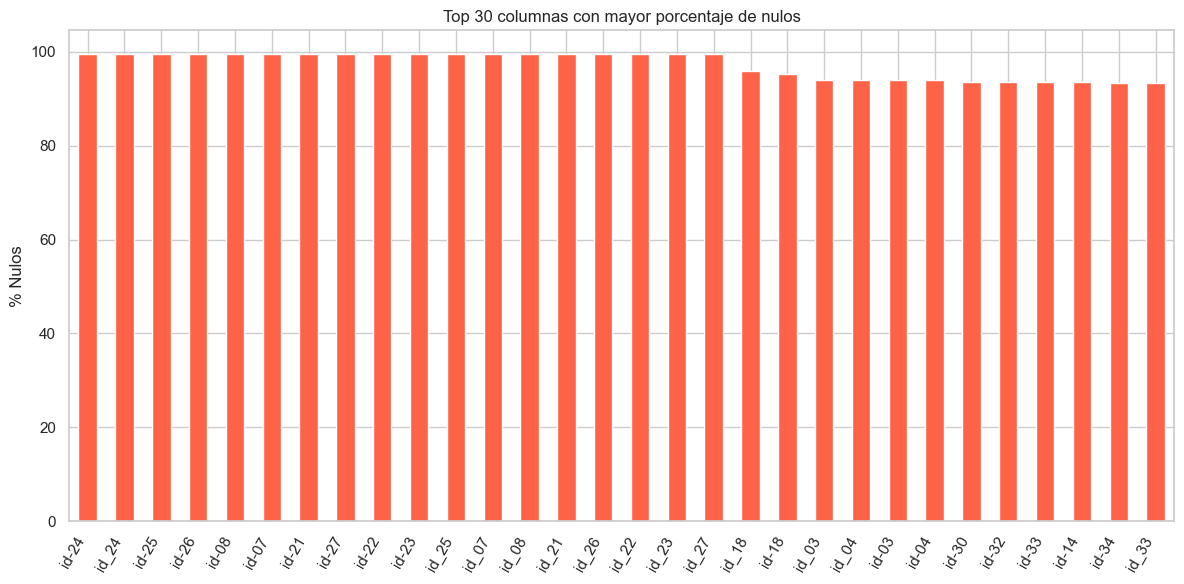

In [8]:
# Visualización: top 30 columnas con más nulos
top_nulls = null_pct.head(30)

plt.figure(figsize=(12, 6))
top_nulls.plot(kind='bar', color='tomato')
plt.title("Top 30 columnas con mayor porcentaje de nulos")
plt.ylabel("% Nulos")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### 5. Variable objetivo — isFraud

In [ ]:
# Distribución de isFraud (solo train)
fraud_counts = train_only[target_col].value_counts()
fraud_pct    = train_only[target_col].value_counts(normalize=True) * 100

print("Conteo:")
print(fraud_counts)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))

fraud_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'salmon'])
axes[0].set_title("Conteo de isFraud")
axes[0].set_xticklabels(['No Fraude (0)', 'Fraude (1)'], rotation=0)



plt.tight_layout()
plt.show()

Conteo:
isFraud
0.0    569877
1.0     20663
Name: count, dtype: int64


ValueError: Number of rows must be a positive integer, not 0

<Figure size 1000x400 with 0 Axes>

### 6. Distribución de variables numéricas clave

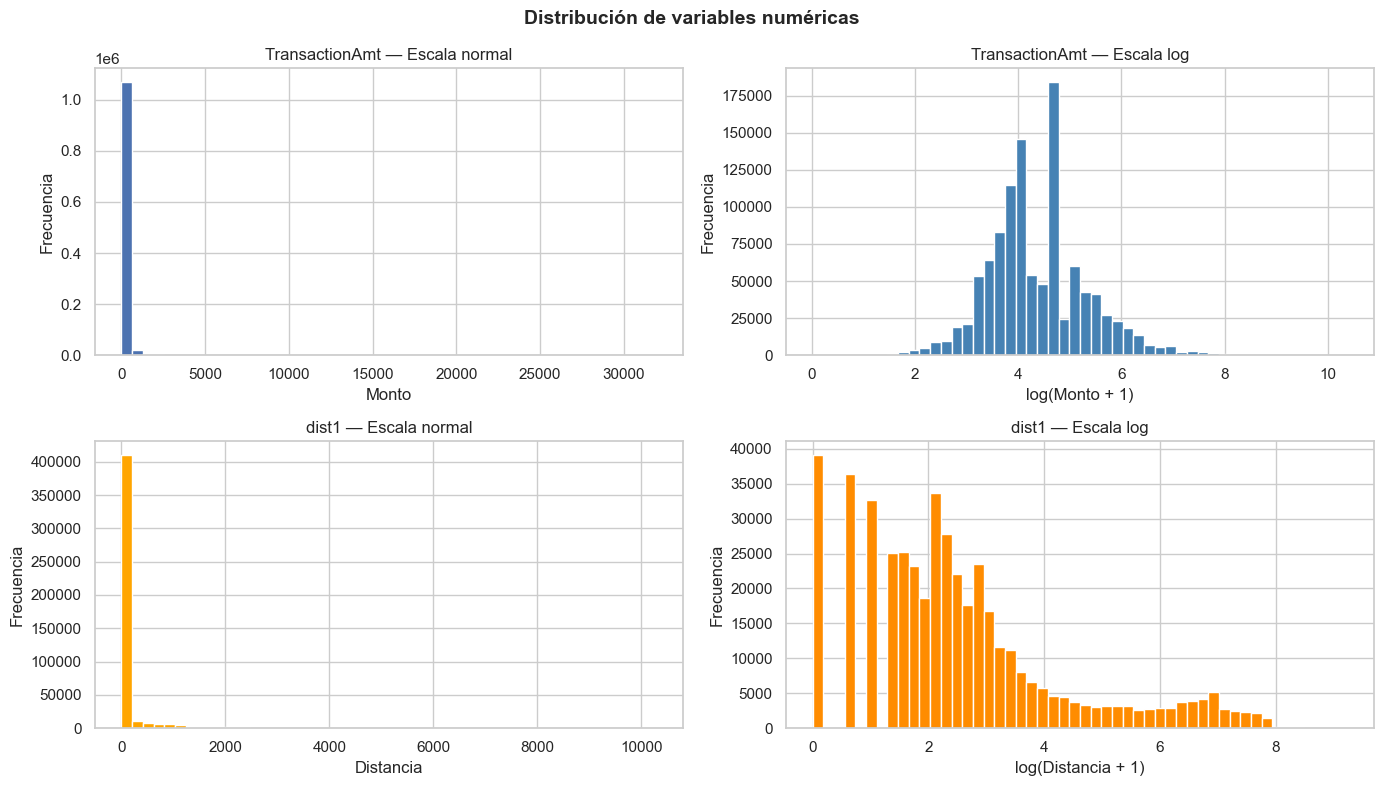

In [10]:
# TransactionAmt y dist1 — escala normal vs log
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# TransactionAmt normal
axes[0, 0].hist(df['TransactionAmt'], bins=50)
axes[0, 0].set_title("TransactionAmt — Escala normal")
axes[0, 0].set_xlabel("Monto")
axes[0, 0].set_ylabel("Frecuencia")

# TransactionAmt log
axes[0, 1].hist(np.log1p(df['TransactionAmt']), bins=50, color='steelblue')
axes[0, 1].set_title("TransactionAmt — Escala log")
axes[0, 1].set_xlabel("log(Monto + 1)")
axes[0, 1].set_ylabel("Frecuencia")

# dist1 normal
axes[1, 0].hist(df['dist1'].dropna(), bins=50, color='orange')
axes[1, 0].set_title("dist1 — Escala normal")
axes[1, 0].set_xlabel("Distancia")
axes[1, 0].set_ylabel("Frecuencia")

# dist1 log
axes[1, 1].hist(np.log1p(df['dist1'].dropna()), bins=50, color='darkorange')
axes[1, 1].set_title("dist1 — Escala log")
axes[1, 1].set_xlabel("log(Distancia + 1)")
axes[1, 1].set_ylabel("Frecuencia")

plt.suptitle("Distribución de variables numéricas", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

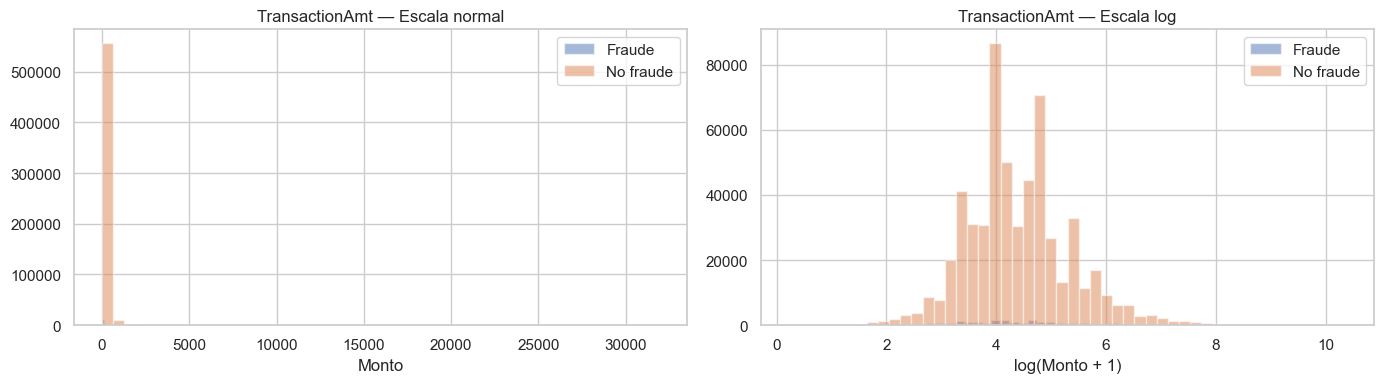

In [11]:
# TransactionAmt vs Fraude (escala logarítmica)
fraud     = train_only[train_only[target_col] == 1]['TransactionAmt']
non_fraud = train_only[train_only[target_col] == 0]['TransactionAmt']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(fraud,     bins=50, alpha=0.5, label='Fraude')
axes[0].hist(non_fraud, bins=50, alpha=0.5, label='No fraude')
axes[0].set_title("TransactionAmt — Escala normal")
axes[0].set_xlabel("Monto")
axes[0].legend()

axes[1].hist(np.log1p(fraud),     bins=50, alpha=0.5, label='Fraude')
axes[1].hist(np.log1p(non_fraud), bins=50, alpha=0.5, label='No fraude')
axes[1].set_title("TransactionAmt — Escala log")
axes[1].set_xlabel("log(Monto + 1)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 7. Análisis temporal — TransactionDT

In [12]:
# TransactionDT está en segundos — extraer hora y día
df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day']  = (df['TransactionDT'] // 86400) % 7

C:\Users\15-4JO\AppData\Local\Temp\ipykernel_29100\2064687792.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['hour'] = (df['TransactionDT'] // 3600) % 24
C:\Users\15-4JO\AppData\Local\Temp\ipykernel_29100\2064687792.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['day']  = (df['TransactionDT'] // 86400) % 7


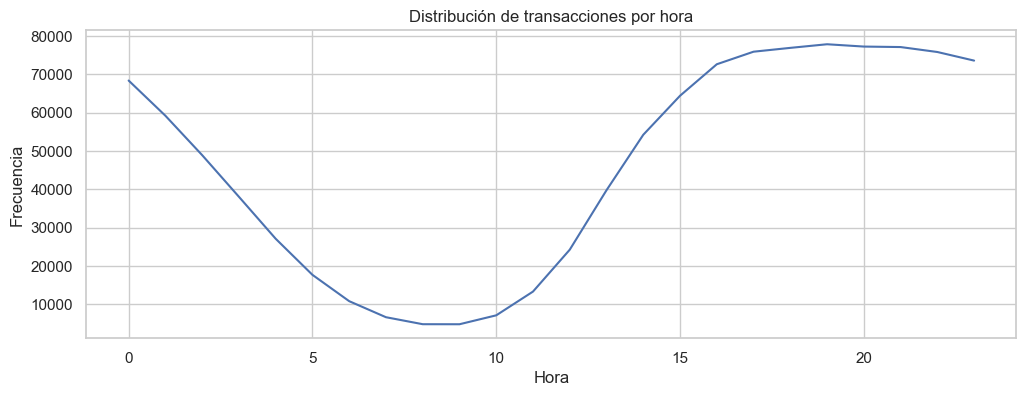

In [13]:
# Distribución de transacciones por hora
df['hour'].value_counts().sort_index().plot(figsize=(12, 4))
plt.title("Distribución de transacciones por hora")
plt.xlabel("Hora")
plt.ylabel("Frecuencia")
plt.show()

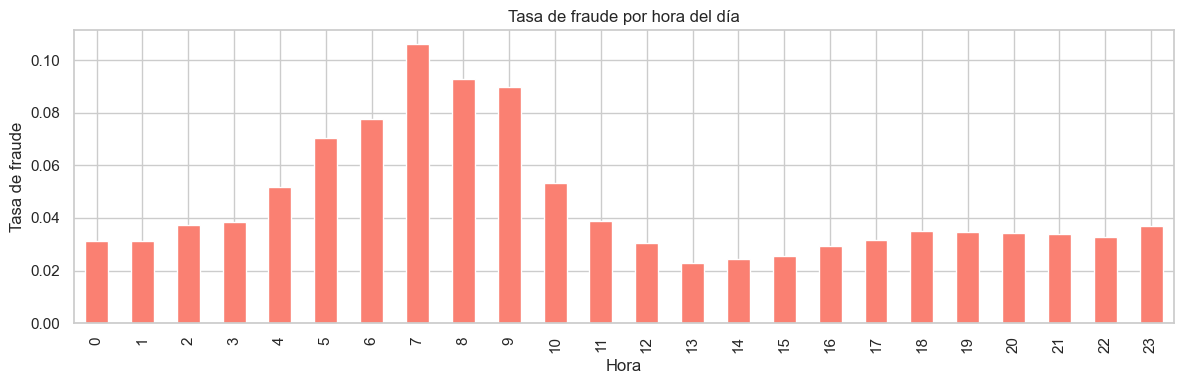

In [14]:
# Tasa de fraude por hora
train_only = df[df['split'] == 'train']  # recalcular con nuevas columnas
fraud_by_hour = train_only.groupby('hour')[target_col].mean()

fraud_by_hour.plot(kind='bar', figsize=(12, 4), color='salmon')
plt.title("Tasa de fraude por hora del día")
plt.xlabel("Hora")
plt.ylabel("Tasa de fraude")
plt.tight_layout()
plt.show()

### 8. Análisis de variables categóricas (transaction)


Column: ProductCD
  Valores únicos : 5
  Valores nulos  : 0 (0.0%)

  Tasa de fraude por categoría:
ProductCD
C    0.116873
S    0.058996
H    0.047662
R    0.037826
W    0.020399
Name: isFraud, dtype: float64


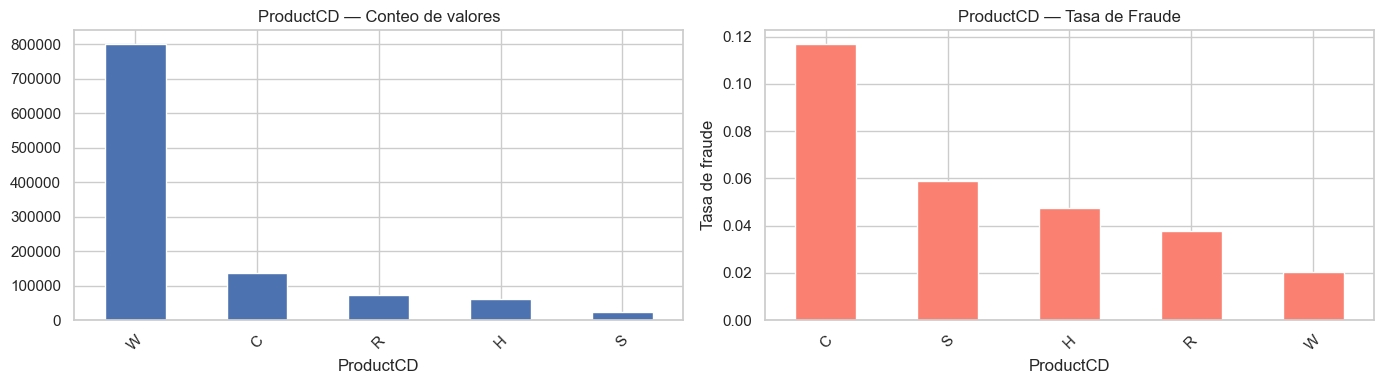


Column: card4
  Valores únicos : 4
  Valores nulos  : 4663 (0.4%)

  Tasa de fraude por categoría:
card4
discover            0.077282
visa                0.034756
mastercard          0.034331
american express    0.028698
Name: isFraud, dtype: float64


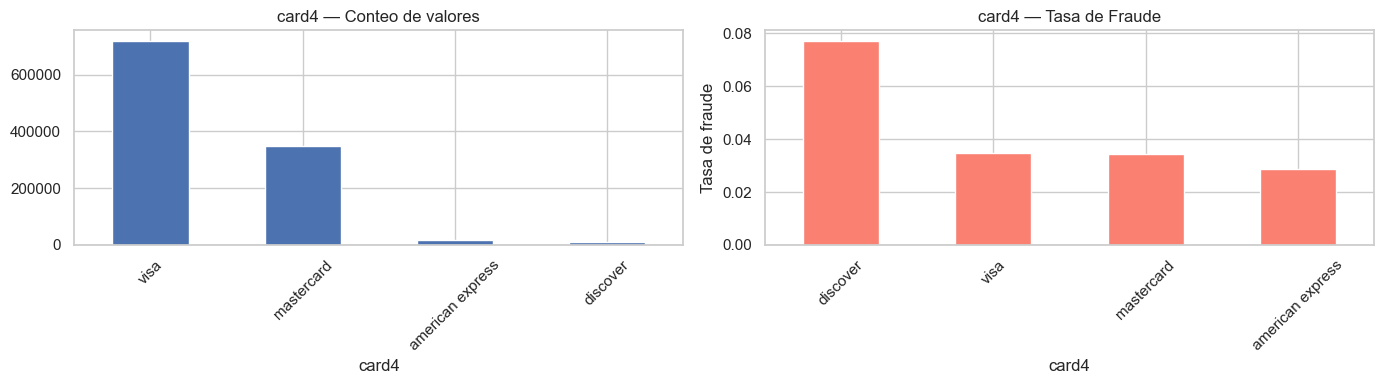


Column: card6
  Valores únicos : 4
  Valores nulos  : 4578 (0.4%)

  Tasa de fraude por categoría:
card6
credit             0.066785
debit              0.024263
charge card        0.000000
debit or credit    0.000000
Name: isFraud, dtype: float64


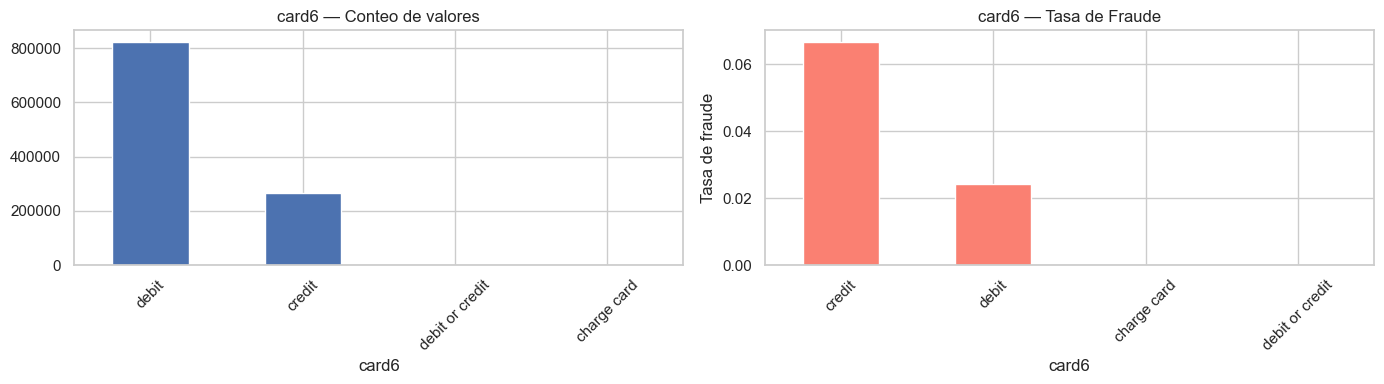


Column: P_emaildomain
  Valores únicos : 60
  Valores nulos  : 163648 (14.9%)

  Tasa de fraude por categoría:
P_emaildomain
protonmail.com    0.407895
mail.com          0.189624
outlook.es        0.130137
aim.com           0.126984
outlook.com       0.094584
hotmail.es        0.065574
live.com.mx       0.054740
hotmail.com       0.052950
gmail.com         0.043542
yahoo.fr          0.034965
Name: isFraud, dtype: float64


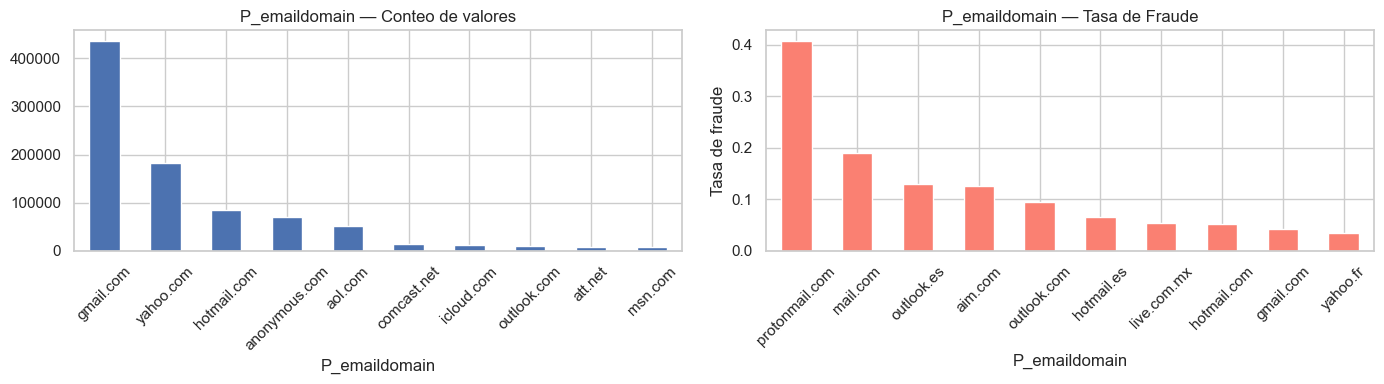


Column: R_emaildomain
  Valores únicos : 60
  Valores nulos  : 824070 (75.1%)

  Tasa de fraude por categoría:
R_emaildomain
protonmail.com    0.951220
mail.com          0.377049
netzero.net       0.222222
outlook.com       0.165138
outlook.es        0.131640
icloud.com        0.128755
gmail.com         0.119184
hotmail.com       0.077793
earthlink.net     0.075949
hotmail.es        0.068493
Name: isFraud, dtype: float64


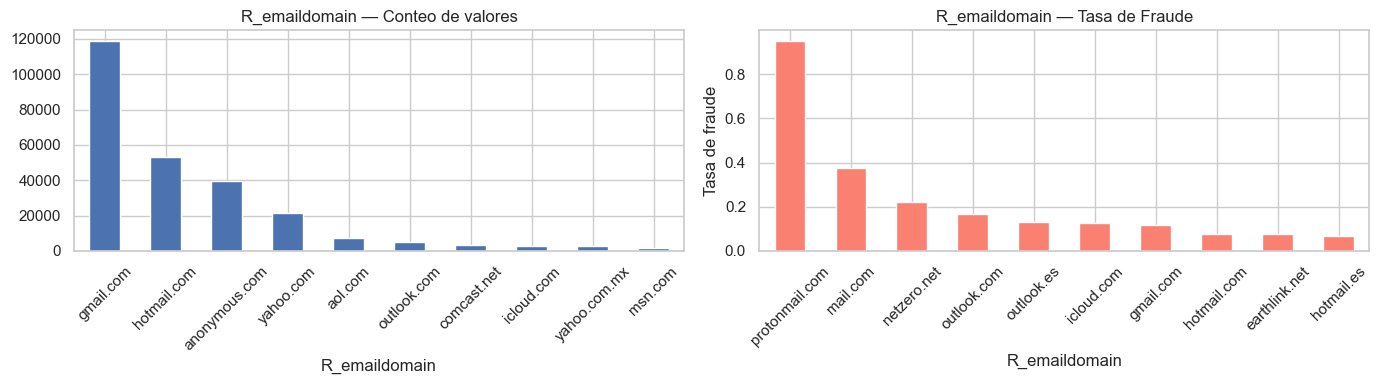


Column: M1
  Valores únicos : 2
  Valores nulos  : 447739 (40.8%)

  Tasa de fraude por categoría:
M1
T    0.019855
F    0.000000
Name: isFraud, dtype: float64


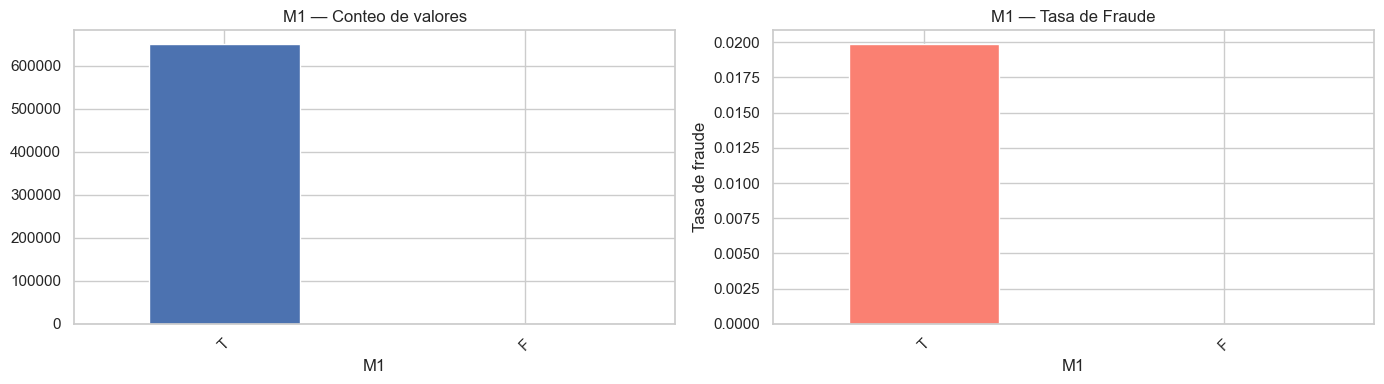


Column: M2
  Valores únicos : 2
  Valores nulos  : 447739 (40.8%)

  Tasa de fraude por categoría:
M2
F    0.034852
T    0.018069
Name: isFraud, dtype: float64


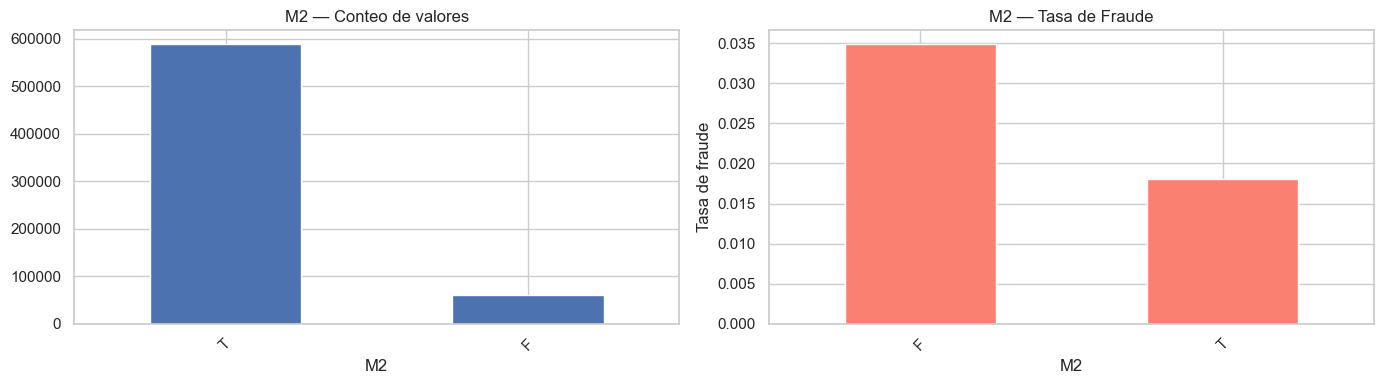


Column: M3
  Valores únicos : 2
  Valores nulos  : 447739 (40.8%)

  Tasa de fraude por categoría:
M3
F    0.030262
T    0.017054
Name: isFraud, dtype: float64


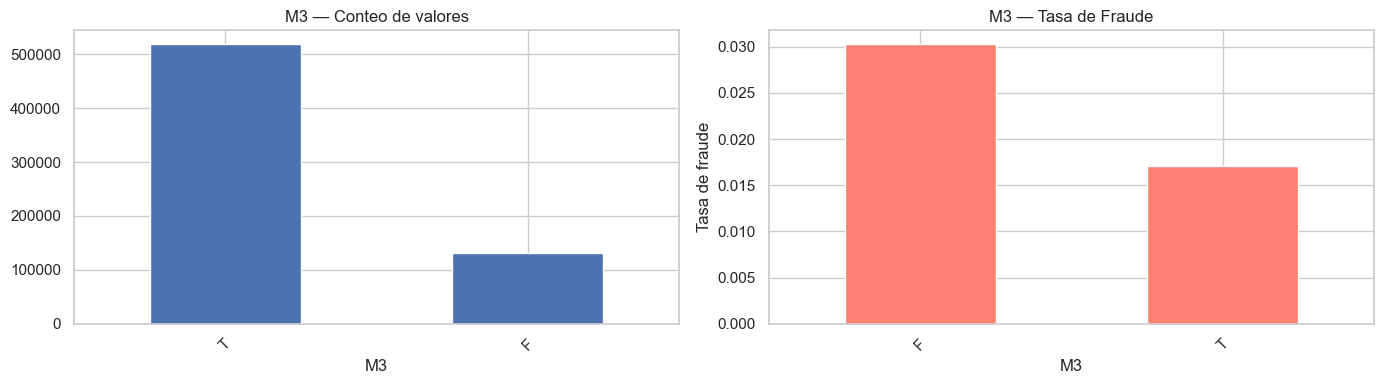


Column: M4
  Valores únicos : 3
  Valores nulos  : 519189 (47.3%)

  Tasa de fraude por categoría:
M4
M2    0.113739
M0    0.036649
M1    0.027051
Name: isFraud, dtype: float64


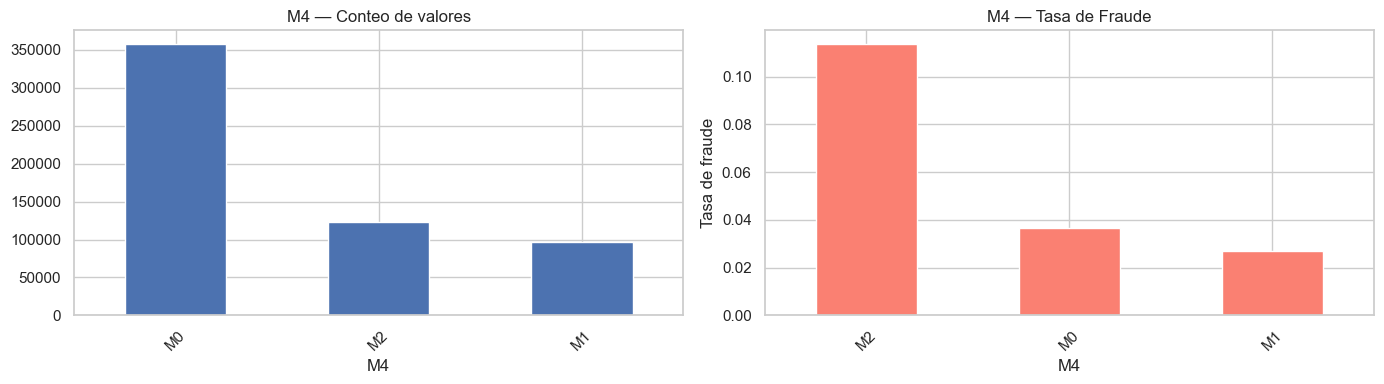


Column: M5
  Valores únicos : 2
  Valores nulos  : 660114 (60.2%)

  Tasa de fraude por categoría:
M5
T    0.037697
F    0.026523
Name: isFraud, dtype: float64


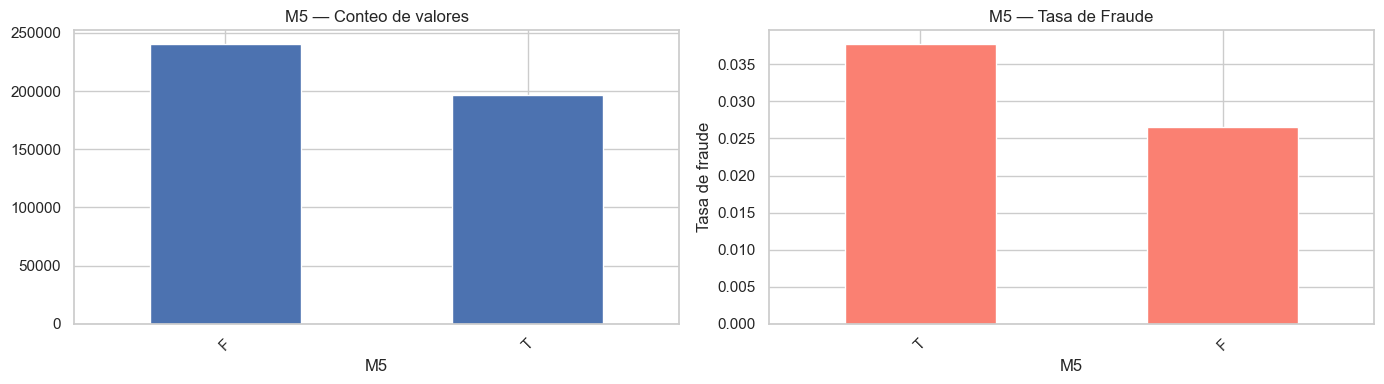


Column: M6
  Valores únicos : 2
  Valores nulos  : 328299 (29.9%)

  Tasa de fraude por categoría:
M6
F    0.023686
T    0.017044
Name: isFraud, dtype: float64


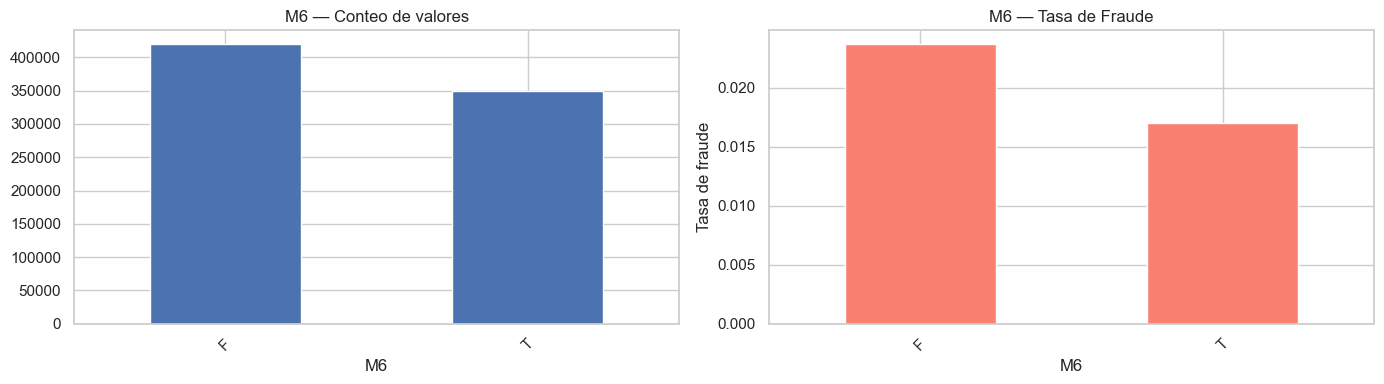


Column: M7
  Valores únicos : 2
  Valores nulos  : 581283 (53.0%)

  Tasa de fraude por categoría:
M7
T    0.022127
F    0.019345
Name: isFraud, dtype: float64


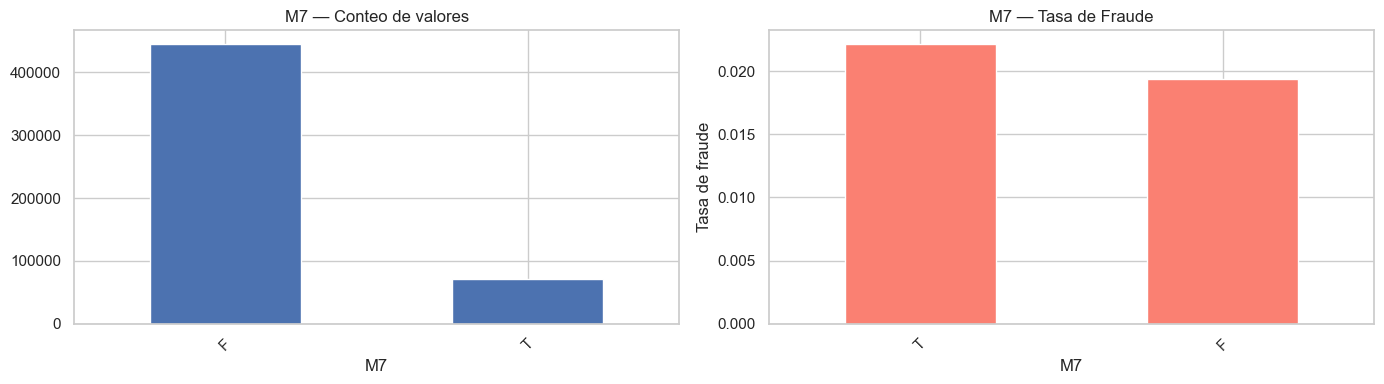


Column: M8
  Valores únicos : 2
  Valores nulos  : 581256 (53.0%)

  Tasa de fraude por categoría:
M8
F    0.021726
T    0.016218
Name: isFraud, dtype: float64


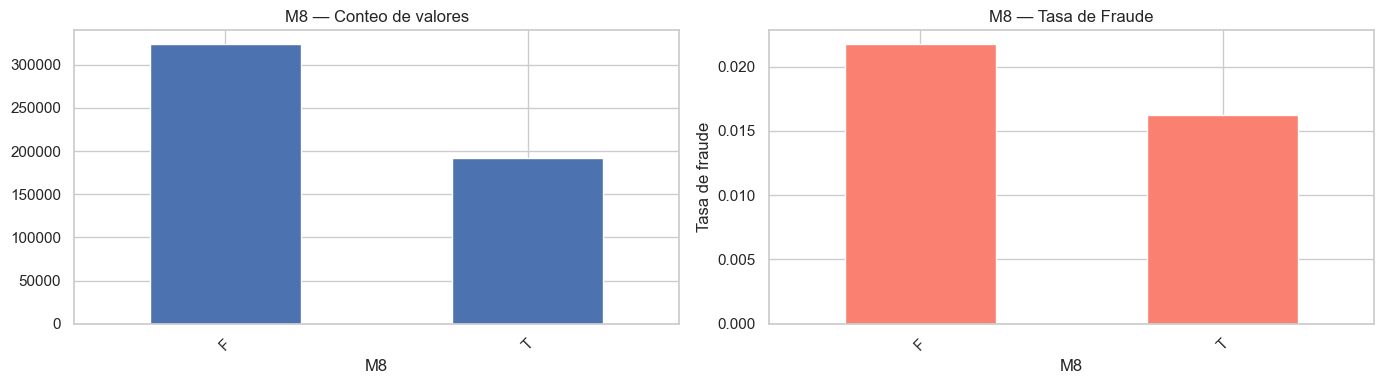


Column: M9
  Valores únicos : 2
  Valores nulos  : 581256 (53.0%)

  Tasa de fraude por categoría:
M9
F    0.030001
T    0.017787
Name: isFraud, dtype: float64


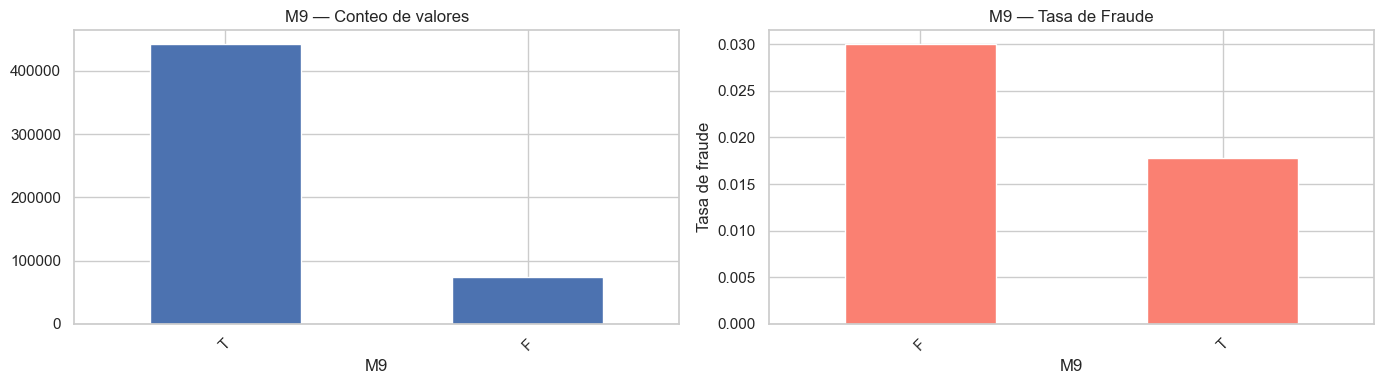

In [15]:
# Variables categóricas de transacción: ProductCD, card4, card6, emails, M1-M9
tx_cat_cols = ['ProductCD', 'card4', 'card6', 'P_emaildomain', 'R_emaildomain',
               'M1', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9']
tx_cat_cols = [c for c in tx_cat_cols if c in df.columns]

for col in tx_cat_cols:
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"  Valores únicos : {df[col].nunique()}")
    print(f"  Valores nulos  : {df[col].isna().sum()} ({df[col].isna().mean()*100:.1f}%)")

    fraud_rate = train_only.groupby(col)[target_col].mean().sort_values(ascending=False)
    print(f"\n  Tasa de fraude por categoría:")
    print(fraud_rate.head(10))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    df[col].value_counts().head(10).plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'{col} — Conteo de valores')
    axes[0].tick_params(axis='x', rotation=45)

    fraud_rate.head(10).plot(kind='bar', ax=axes[1], color='salmon')
    axes[1].set_title(f'{col} — Tasa de Fraude')
    axes[1].set_ylabel('Tasa de fraude')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

### 9. Análisis de variables categóricas (identity)


Column: DeviceType
  Valores únicos : 2
  Valores nulos  : 819490 (74.7%)

  Tasa de fraude por categoría:
DeviceType
mobile     0.101662
desktop    0.065215
Name: isFraud, dtype: float64


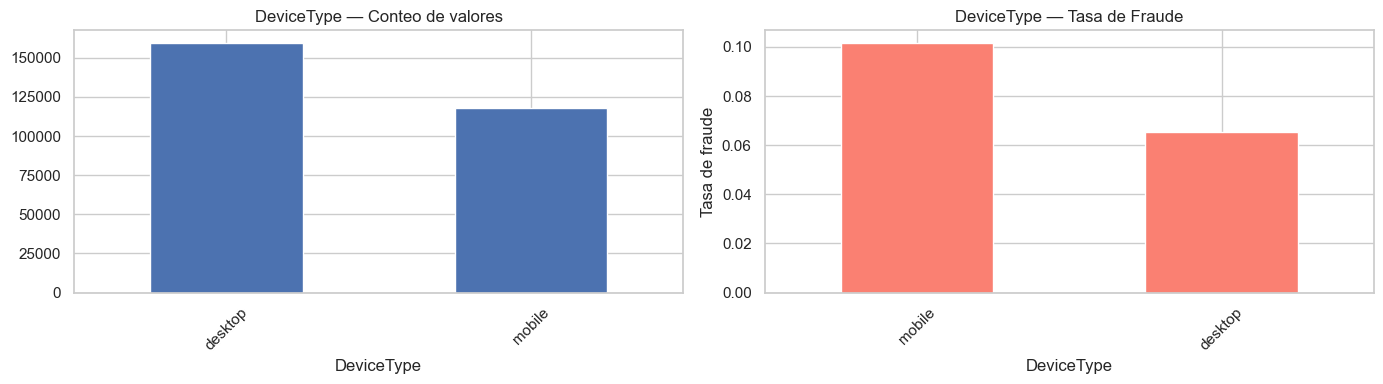


Column: DeviceInfo
  Valores únicos : 2799
  Valores nulos  : 863508 (78.7%)

  Tasa de fraude por categoría:
DeviceInfo
ZTE-Z835                       1.0
Dream                          1.0
SM-T285M                       1.0
A5002                          1.0
A466BG                         1.0
SM-T530                        1.0
Blade L3 Build/KOT49H          1.0
RNE-L23 Build/HUAWEIRNE-L23    1.0
SAMSUNG-SM-N900A               1.0
MotoG3-TE Build/MPD24.65-33    1.0
Name: isFraud, dtype: float64


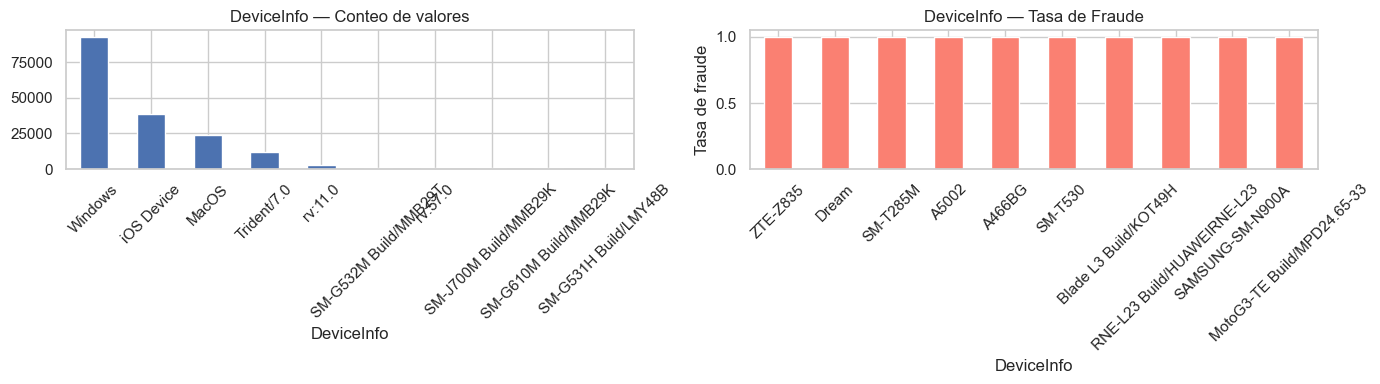


Column: id_12
  Valores únicos : 2
  Valores nulos  : 952998 (86.9%)

  Tasa de fraude por categoría:
id_12
NotFound    0.081683
Found       0.059836
Name: isFraud, dtype: float64


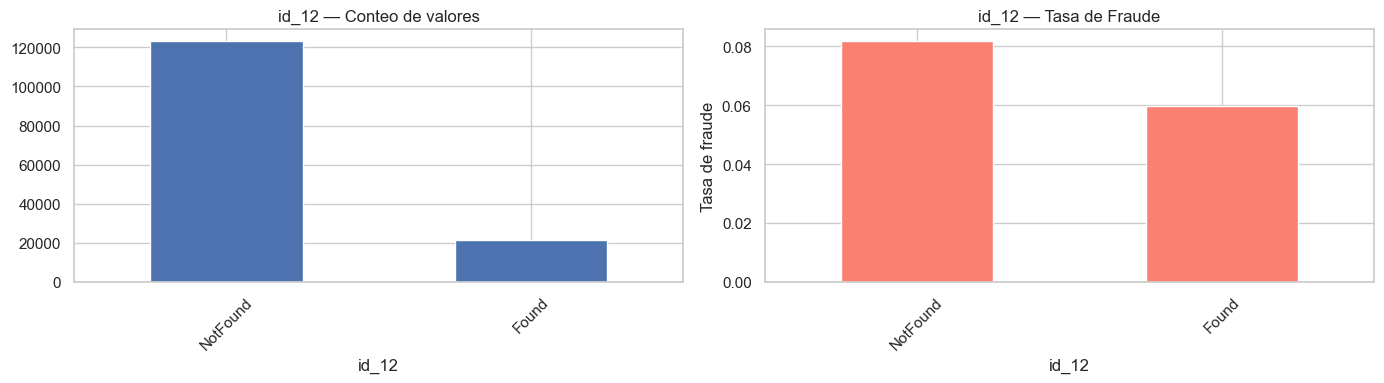


Column: id_15
  Valores únicos : 3
  Valores nulos  : 956246 (87.2%)

  Tasa de fraude por categoría:
id_15
Found      0.105097
Unknown    0.091885
New        0.049244
Name: isFraud, dtype: float64


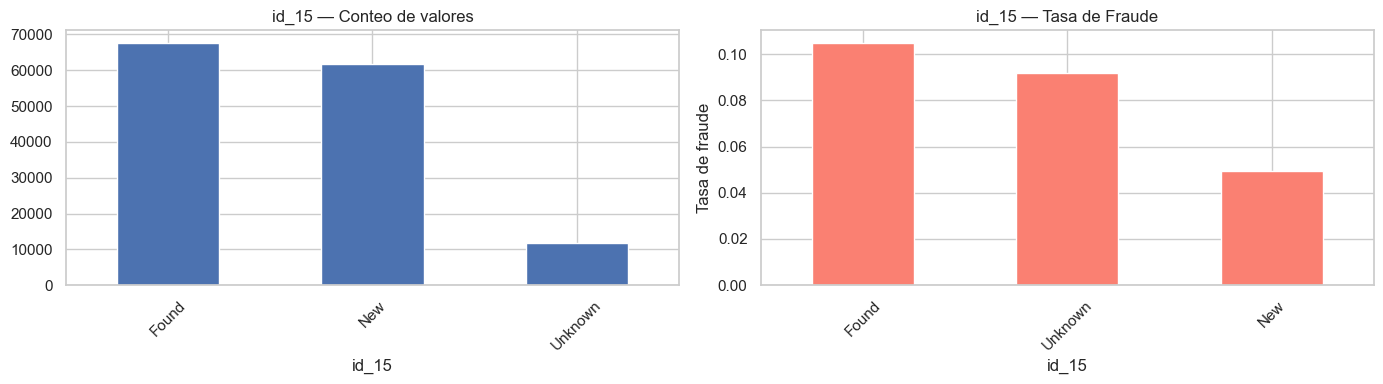


Column: id_16
  Valores únicos : 2
  Valores nulos  : 967891 (88.2%)

  Tasa de fraude por categoría:
id_16
Found       0.107231
NotFound    0.048242
Name: isFraud, dtype: float64


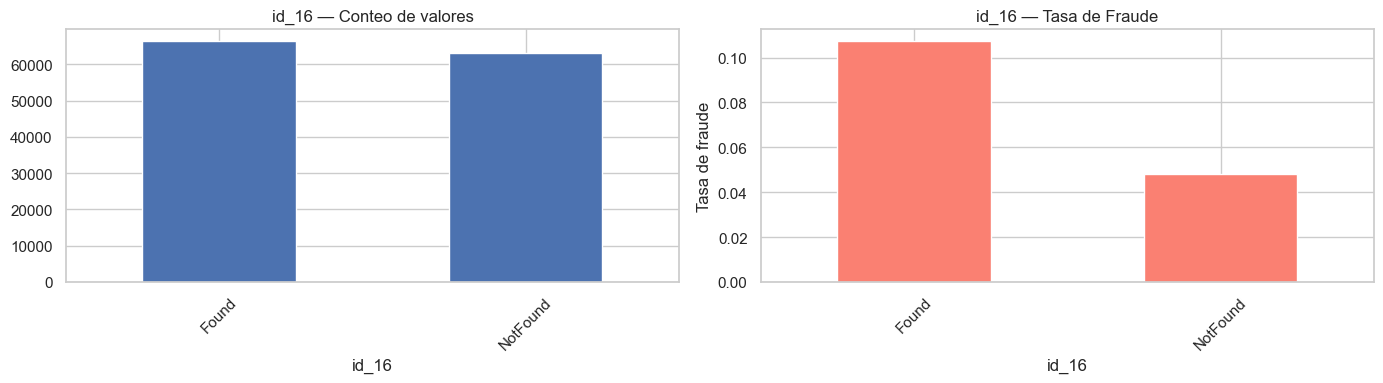


Column: id_23
  Valores únicos : 3
  Valores nulos  : 1092062 (99.5%)

  Tasa de fraude por categoría:
id_23
IP_PROXY:ANONYMOUS      0.137255
IP_PROXY:TRANSPARENT    0.070221
IP_PROXY:HIDDEN         0.055829
Name: isFraud, dtype: float64


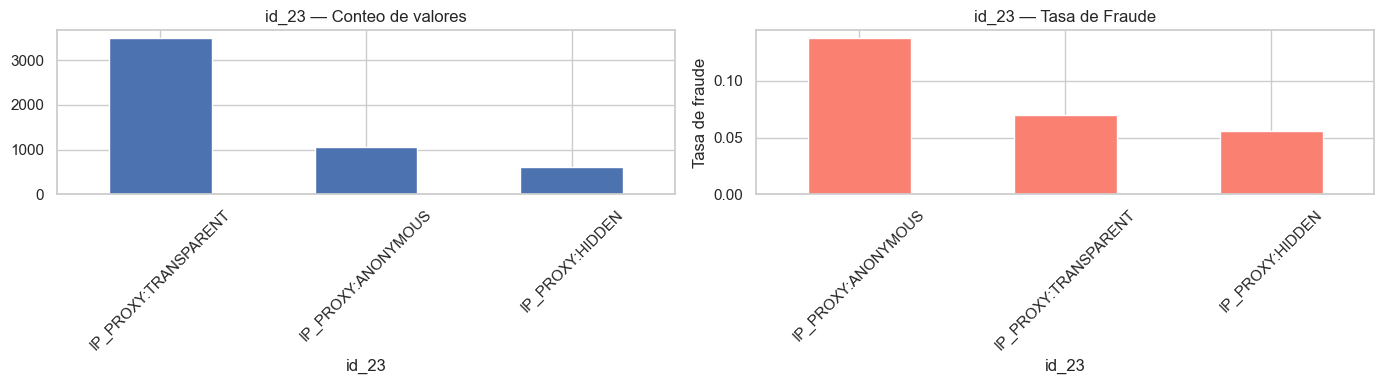


Column: id_27
  Valores únicos : 2
  Valores nulos  : 1092062 (99.5%)

  Tasa de fraude por categoría:
id_27
Found       0.082638
NotFound    0.000000
Name: isFraud, dtype: float64


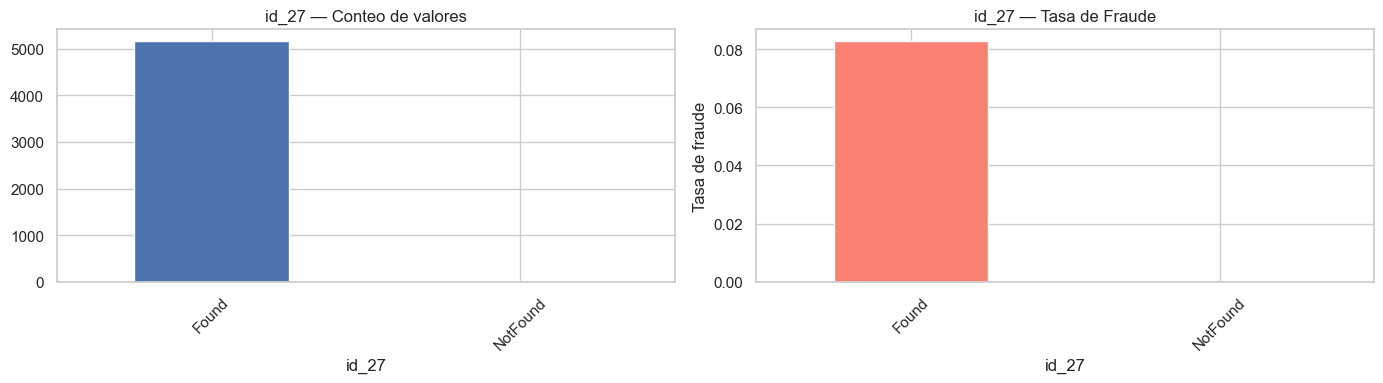


Column: id_28
  Valores únicos : 2
  Valores nulos  : 956253 (87.2%)

  Tasa de fraude por categoría:
id_28
Found    0.102752
New      0.052281
Name: isFraud, dtype: float64


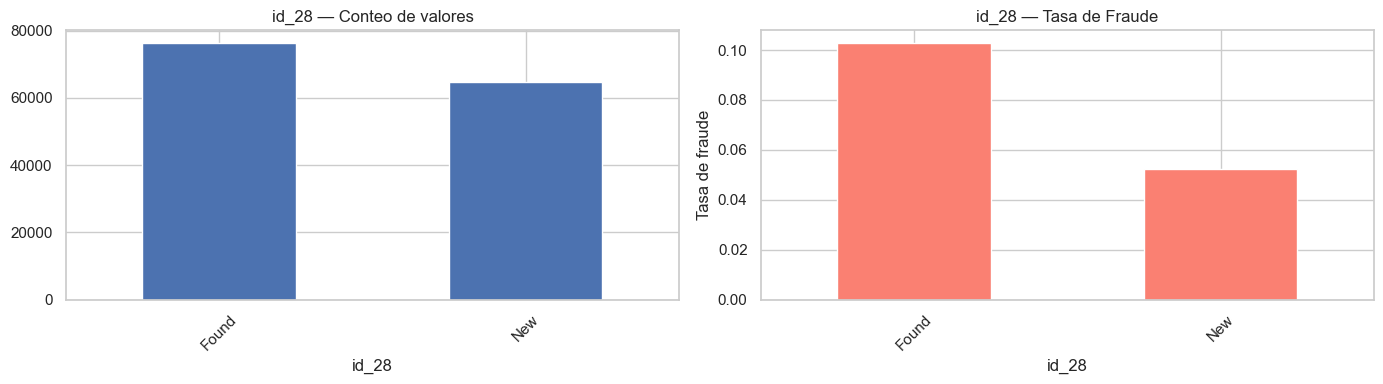


Column: id_29
  Valores únicos : 2
  Valores nulos  : 956253 (87.2%)

  Tasa de fraude por categoría:
id_29
Found       0.104463
NotFound    0.051338
Name: isFraud, dtype: float64


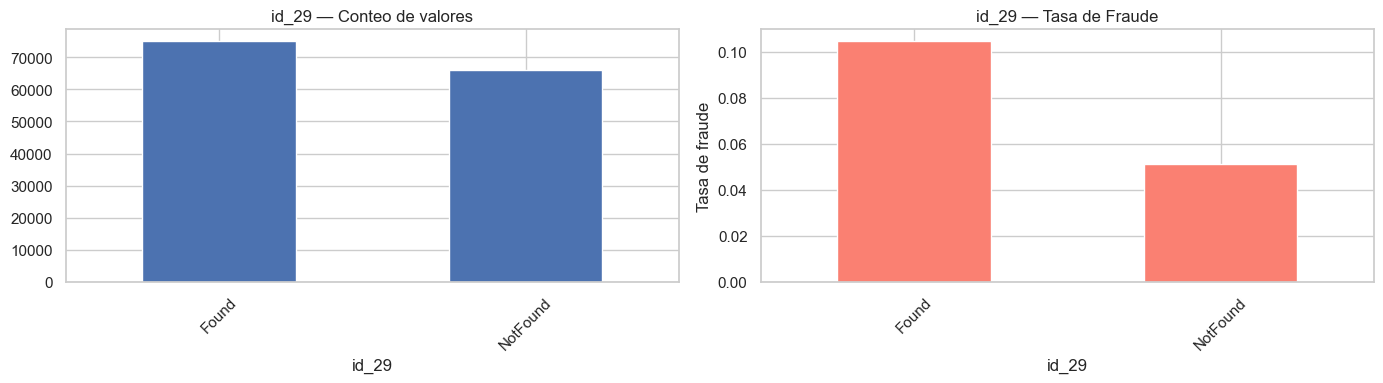


Column: id_30
  Valores únicos : 75
  Valores nulos  : 1019666 (92.9%)

  Tasa de fraude por categoría:
id_30
other            0.600000
Android 5.1.1    0.288571
Android 4.4.2    0.253968
iOS 11.4.0       0.200000
iOS 11.0.1       0.196850
iOS 11.1.0       0.177122
iOS 11.2.5       0.121667
Android 7.1.2    0.121212
iOS 11.2.2       0.117517
Windows 8        0.116667
Name: isFraud, dtype: float64


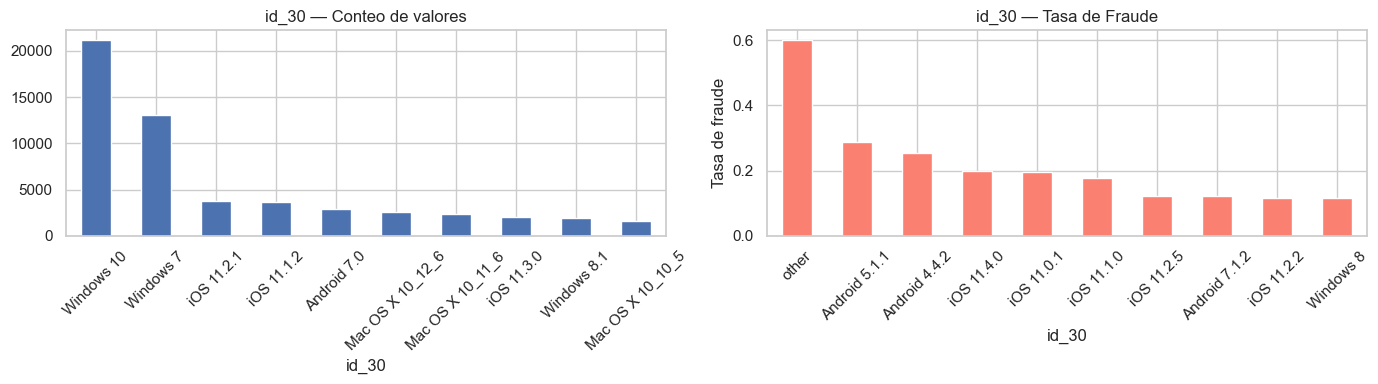


Column: id_31
  Valores únicos : 130
  Valores nulos  : 956949 (87.2%)

  Tasa de fraude por categoría:
id_31
Mozilla/Firefox            1.000000
icedragon                  1.000000
comodo                     0.666667
Lanix/Ilium                0.666667
chrome 49.0 for android    0.547170
opera                      0.481928
opera generic              0.448718
chrome 52.0 for android    0.381579
opera 49.0                 0.311594
samsung browser 5.4        0.302326
Name: isFraud, dtype: float64


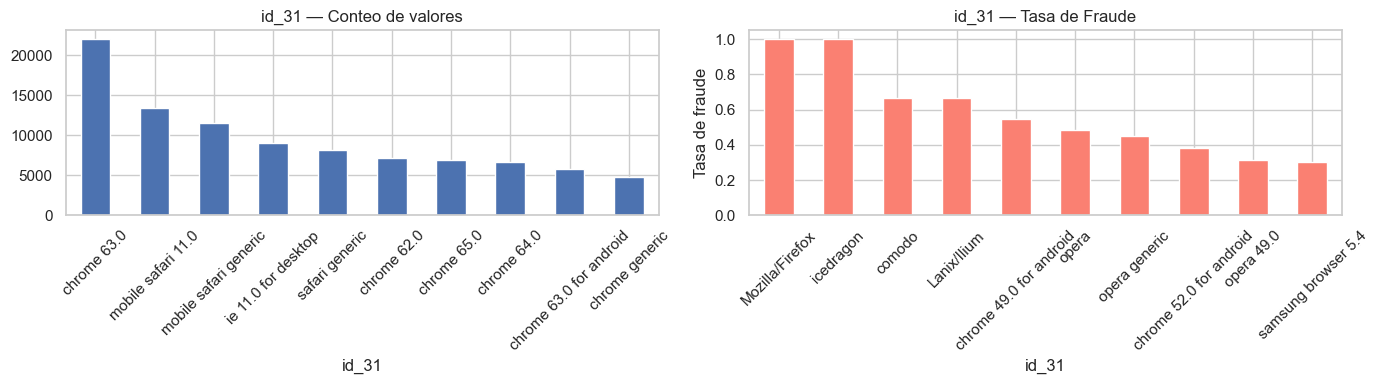


Column: id_33
  Valores únicos : 260
  Valores nulos  : 1023942 (93.3%)

  Tasa de fraude por categoría:
id_33
1440x759     1.000000
640x360      1.000000
1916x901     1.000000
1024x552     1.000000
2076x1080    1.000000
1920x975     1.000000
1364x768     0.842105
4500x3000    0.666667
1024x600     0.647727
1768x992     0.600000
Name: isFraud, dtype: float64


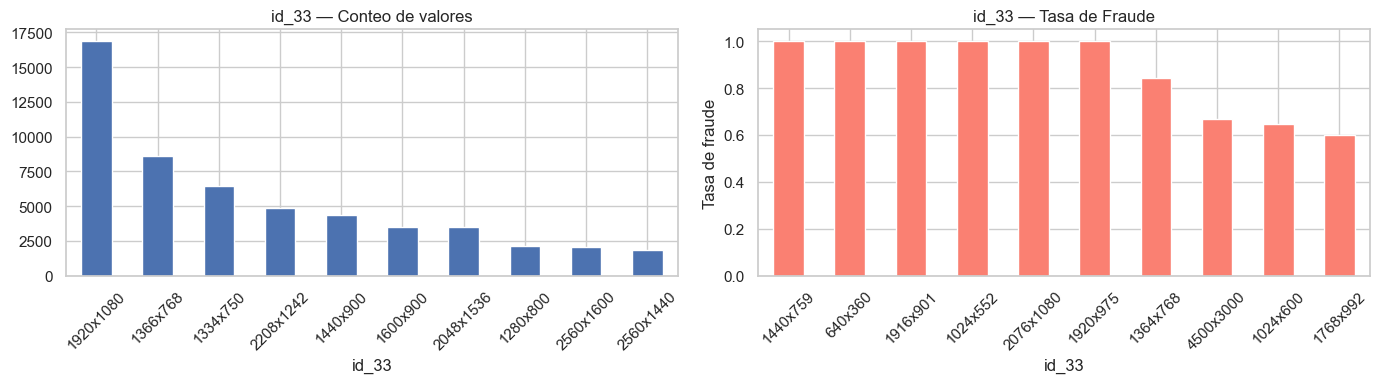


Column: id_34
  Valores únicos : 4
  Valores nulos  : 1019426 (92.9%)

  Tasa de fraude por categoría:
id_34
match_status:1     0.063651
match_status:0     0.050602
match_status:2     0.039293
match_status:-1    0.000000
Name: isFraud, dtype: float64


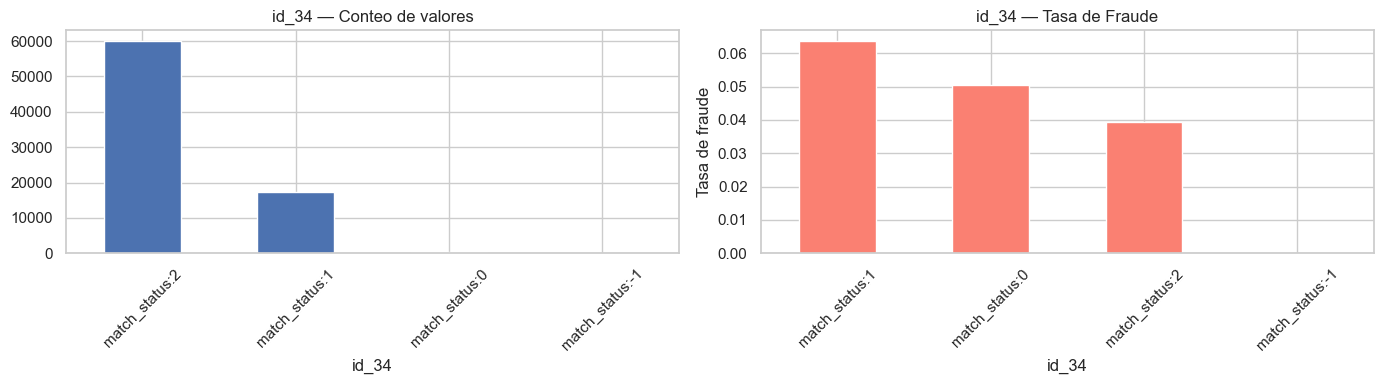


Column: id_35
  Valores únicos : 2
  Valores nulos  : 956246 (87.2%)

  Tasa de fraude por categoría:
id_35
F    0.122604
T    0.044683
Name: isFraud, dtype: float64


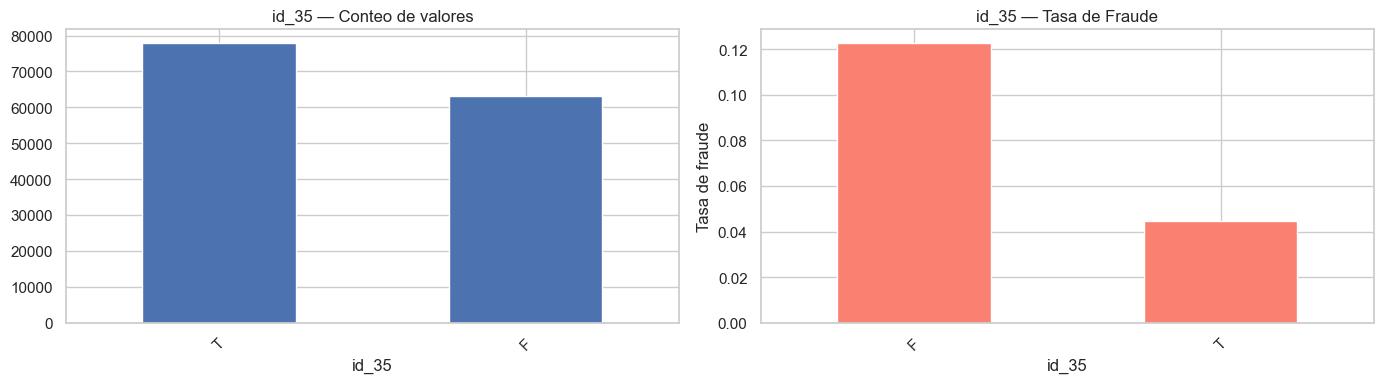


Column: id_36
  Valores únicos : 2
  Valores nulos  : 956246 (87.2%)

  Tasa de fraude por categoría:
id_36
F    0.081885
T    0.035265
Name: isFraud, dtype: float64


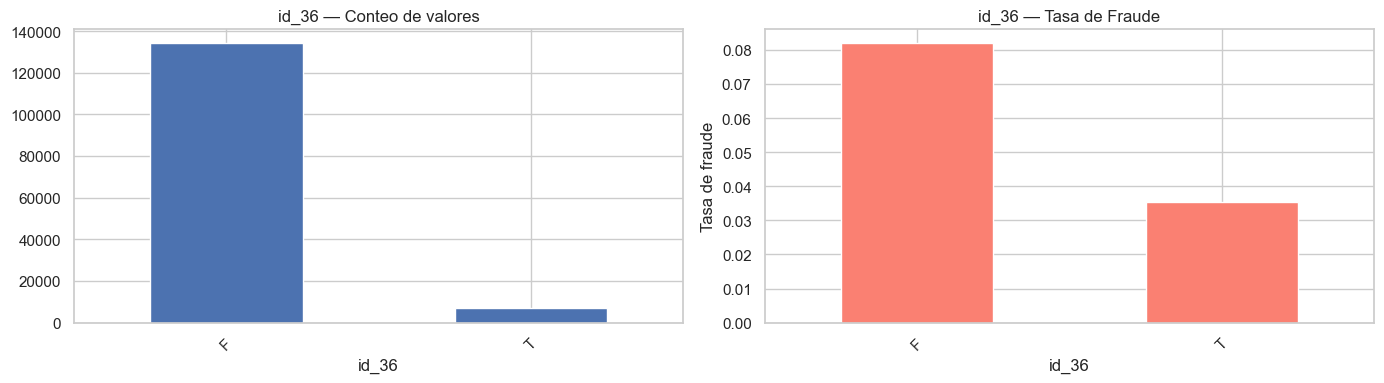


Column: id_37
  Valores únicos : 2
  Valores nulos  : 956246 (87.2%)

  Tasa de fraude por categoría:
id_37
T    0.083312
F    0.066158
Name: isFraud, dtype: float64


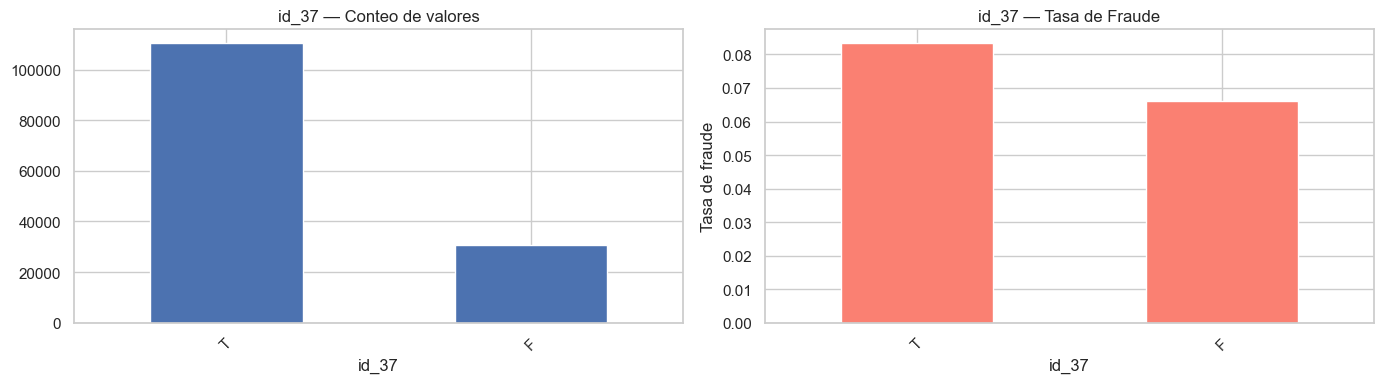


Column: id_38
  Valores únicos : 2
  Valores nulos  : 956246 (87.2%)

  Tasa de fraude por categoría:
id_38
F    0.097792
T    0.059541
Name: isFraud, dtype: float64


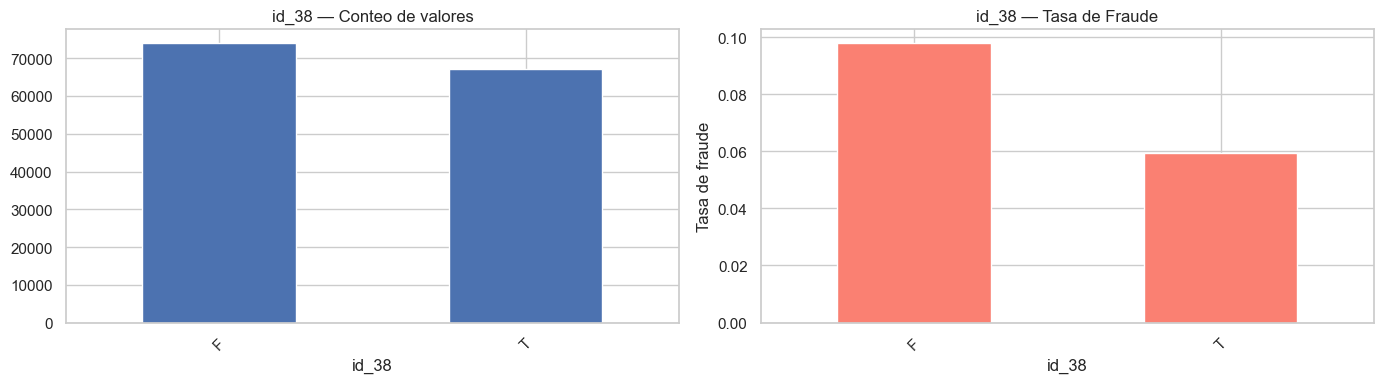

In [16]:
# Variables categóricas de identidad: DeviceType, DeviceInfo, id_12, id_15, id_16, id_23, id_27-id_29
id_cat_cols = ['DeviceType', 'DeviceInfo', 'id_12', 'id_15', 'id_16',
               'id_23', 'id_27', 'id_28', 'id_29', 'id_30', 'id_31', 'id_33', 'id_34', 'id_35', 'id_36', 'id_37', 'id_38']
id_cat_cols = [c for c in id_cat_cols if c in df.columns]

for col in id_cat_cols:
    print(f"\n{'='*40}")
    print(f"Column: {col}")
    print(f"  Valores únicos : {df[col].nunique()}")
    print(f"  Valores nulos  : {df[col].isna().sum()} ({df[col].isna().mean()*100:.1f}%)")

    fraud_rate = train_only.groupby(col)[target_col].mean().sort_values(ascending=False)
    print(f"\n  Tasa de fraude por categoría:")
    print(fraud_rate.head(10))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    df[col].value_counts().head(10).plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'{col} — Conteo de valores')
    axes[0].tick_params(axis='x', rotation=45)

    fraud_rate.head(10).plot(kind='bar', ax=axes[1], color='salmon')
    axes[1].set_title(f'{col} — Tasa de Fraude')
    axes[1].set_ylabel('Tasa de fraude')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

### 10. DeviceType y DeviceInfo

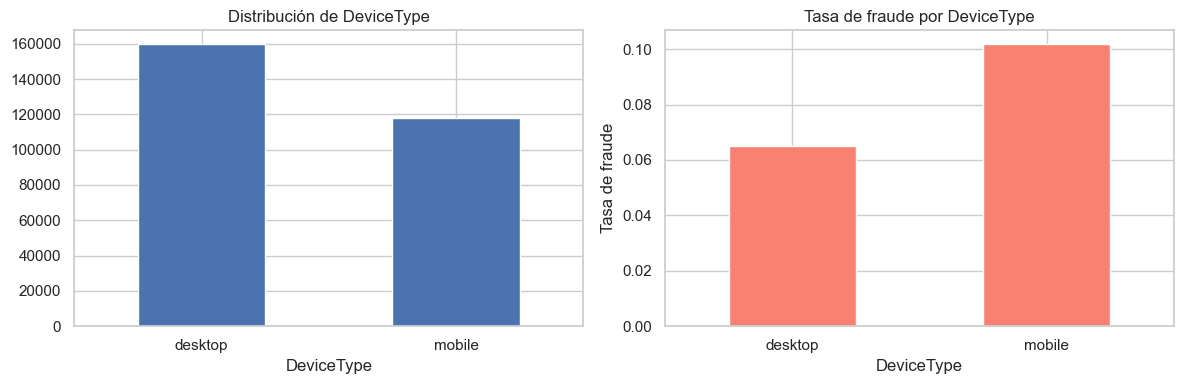

In [17]:
# DeviceType: mobile vs desktop
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['DeviceType'].value_counts().plot(kind='bar', ax=axes[0])
axes[0].set_title("Distribución de DeviceType")
axes[0].tick_params(axis='x', rotation=0)

train_only.groupby('DeviceType')[target_col].mean().plot(kind='bar', ax=axes[1], color='salmon')
axes[1].set_title("Tasa de fraude por DeviceType")
axes[1].set_ylabel("Tasa de fraude")
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

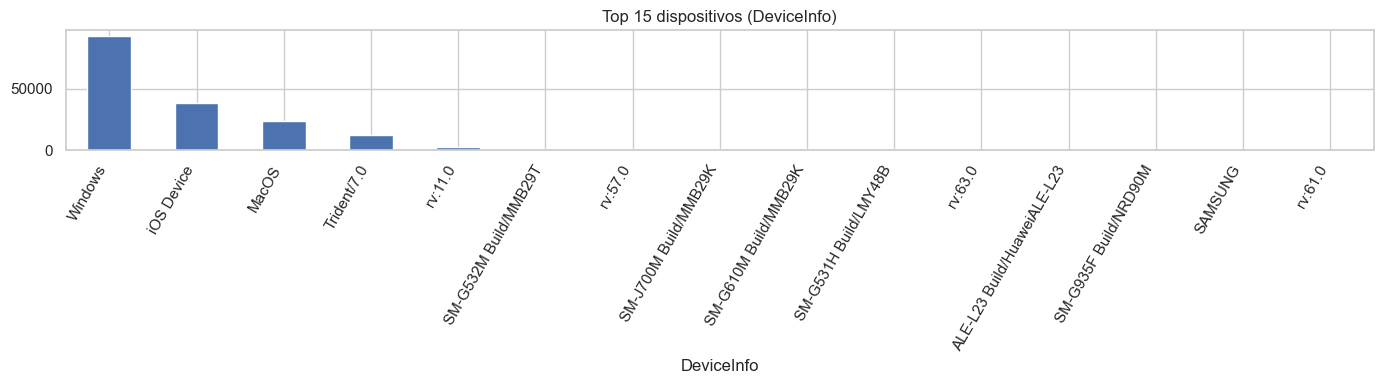

In [18]:
# Top 15 dispositivos más comunes
df['DeviceInfo'].value_counts().head(15).plot(kind='bar', figsize=(14, 4))
plt.title("Top 15 dispositivos (DeviceInfo)")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### 11. Outliers en TransactionAmt

In [19]:
# Detección de outliers con IQR
Q1  = df['TransactionAmt'].quantile(0.25)
Q3  = df['TransactionAmt'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['TransactionAmt'] < Q1 - 1.5*IQR) | (df['TransactionAmt'] > Q3 + 1.5*IQR)]

print(f"Outliers en TransactionAmt: {outliers.shape[0]} ({outliers.shape[0]/len(df)*100:.2f}%)") 

Outliers en TransactionAmt: 123078 (11.22%)


### 12. Correlación con isFraud

V257    0.383060
V246    0.366878
V244    0.364129
V242    0.360590
V201    0.328005
V200    0.318783
V189    0.308219
V188    0.303582
V258    0.297151
V45     0.281832
V158    0.278066
V156    0.275952
V149    0.273282
V228    0.268861
V44     0.260376
V86     0.251828
V87     0.251737
V170    0.249794
V147    0.242894
V52     0.239469
Name: isFraud, dtype: float64


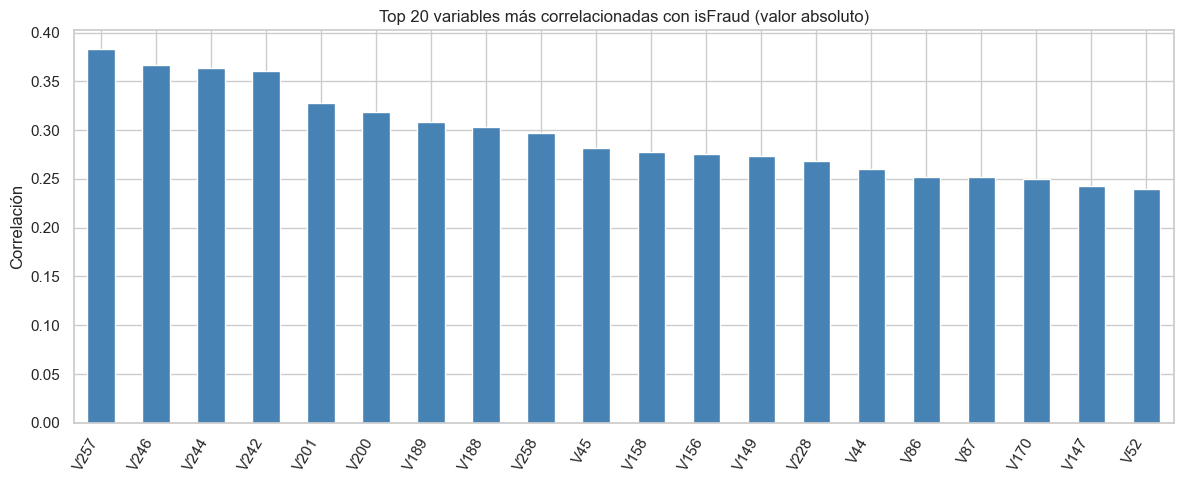

In [20]:
# Top 20 variables más correlacionadas con isFraud
corr = train_only.corr(numeric_only=True)
top_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False).head(20)

print(top_corr)

top_corr.plot(kind='bar', figsize=(12, 5), color='steelblue')
plt.title("Top 20 variables más correlacionadas con isFraud (valor absoluto)")
plt.ylabel("Correlación")
plt.xticks(rotation=60, ha='right')
plt.tight_layout()
plt.show()

### 13. Conclusiones del EDA

El análisis exploratorio muestra que las variables individuales presentan una correlación extremadamente baja con la variable objetivo isFraud. Las variables continuas como TransactionAmt y dist1 siguen distribuciones log-normales, típicas de datos financieros, pero no presentan diferencias significativas entre transacciones fraudulentas y no fraudulentas.

Las variables categóricas de identidad como DeviceType, id_12, id_15 y id_31 muestran variaciones más interesantes en la tasa de fraude. El dataset presenta un fuerte desbalance de clases en isFraud, lo cual deberá ser considerado en el modelado.

El fenómeno del fraude no es lineal ni dependiente de una sola variable, lo que justifica el uso de un modelo como MLP capaz de capturar relaciones no lineales entre múltiples variables.
